In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
import random
import numpy as np
import torch
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.mps.deterministic = True
torch.use_deterministic_algorithms(True)

## training a VAE

In [3]:
import torch
import rdkit
from rdkit import Chem
print(torch.__version__)
print(Chem.MolFromSmiles("CCO"))

2.11.0


In [4]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
split = data.get_split()
train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")
train_df.head()

Found local copy...
Loading...
Done!


Train: 9191, Valid: 1313, Test: 2626


,Drug_ID,Drug,Y
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,0
1,644890.0,COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1,1
2,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0
3,6602688.0,Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c...,1
4,645448.0,CCC(C)(C)NC(=O)c1ccc2c(c1)N(CC(=O)OC)C(=O)C(C)...,0


## filter out '.' from the SMILES strings because it represents multiple disconnected molecules written as one string.

## + optional SMILES augmentation (im leaving it for now)

In [5]:
def augment_smiles(smi, n=10):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return [smi]
    variants = set()
    variants.add(Chem.MolToSmiles(mol))  # canonical
    for _ in range(n):
        variants.add(Chem.MolToSmiles(mol, doRandom=True))
    return list(variants)

In [6]:
from rdkit import Chem

def keep_largest_fragment(smi):
    if '.' not in smi:
        return smi
    frags = smi.split('.')
    mols = [(Chem.MolFromSmiles(f), f) for f in frags]
    mols = [(m, f) for m, f in mols if m is not None]
    if not mols:
        return None
    return max(mols, key=lambda x: x[0].GetNumHeavyAtoms())[1]

for df in [train_df, valid_df, test_df]:
    df['Drug'] = df['Drug'].apply(keep_largest_fragment)
    df.dropna(subset=['Drug'], inplace=True)
    # MAX_LENGTH = 100 includes <sos> and <eos>, so SMILES can be at most 98 chars
    df.drop(df[df['Drug'].str.len() > 98].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"After filtering — Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

#augmented_rows = []
#for _, row in train_df.iterrows():
 #   for smi in augment_smiles(row['Drug'], n=3):
  #      augmented_rows.append({'Drug': smi, 'Y': row['Y']})

#train_df = pd.DataFrame(augmented_rows).reset_index(drop=True)
#print(f"Original train size: {len(split['train'])}")
#print(f"Augmented train size: {len(train_df)}")

After filtering — Train: 8990, Valid: 1291, Test: 2570


In [7]:
full_df = pd.concat([split['train'], valid_df, test_df])
print(full_df['Y'].value_counts())
print(full_df['Y'].value_counts(normalize=True))

Y
0    10359
1     2492
Name: count, dtype: int64
Y
0    0.806085
1    0.193915
Name: proportion, dtype: float64


## building the character vocabulary
we start off by building the character vocabulary, since a VAE encodes smiles strings into a latent vector. a neural network cant take raw text - only numbers, so we convert each character in a smiles string to an integer.

`<pad>` - used to make all SMILES the same length in a batch (token = 0)

`<sos>` - start of sequence, tells the decoder to begin generating (token = 1)

`<eos>` - end of sequence, tells the decoder to stop (token = 2)

!!!! this can raise an issue because neural networks care abt what the numbers mean - check the thing with 0 and 1s (one hot encodding)

In [8]:
train_smiles = train_df['Drug'].tolist()
valid_smiles = valid_df['Drug'].tolist()
test_smiles  = test_df['Drug'].tolist()
df = pd.concat([train_df, valid_df, test_df])
all_smiles = df['Drug'].tolist()
vocab = sorted(set(''.join(all_smiles)))
vocab = ['<pad>', '<sos>', '<eos>'] + vocab

char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

Vocabulary size: 41
Characters: ['<pad>', '<sos>', '<eos>', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's']


Next step is to check the distribution of SMILES lengths to configure padding

Max length: 98
Mean length: 43.6
95th percentile: 72


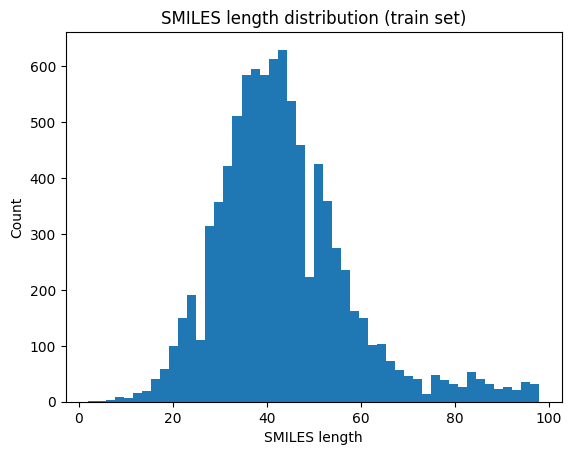

In [9]:
import matplotlib.pyplot as plt

lengths = [len(s) for s in train_smiles]
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95*len(lengths))]}")

plt.hist(lengths, bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("SMILES length distribution (train set)")
plt.show()

# this graph ^^ has changed because i removed all SMILES with char_len >100

the distribution is right-skewed, with a mean length of smiles strings being 46.1 (small molecules) and the 95th percentile is 85, so we set `max_length` = 100

## Tokenization and Encoding of SMILES 

In [10]:
import torch

MAX_LENGTH = 100

def encode_smiles(smiles, char2idx, max_length):
    """
    Convert a SMILES string to a fixed-length integer sequence.
    
    Wraps the sequence with <sos> and <eos> tokens, truncates sequences
    longer than max_length, and pads shorter sequences with <pad> tokens.
    
    Args:
        smiles (str): SMILES string of a molecule.
        char2idx (dict): mapping from character to integer index.
        max_length (int): fixed length for all output sequences.
    
    Returns:
        list[int]: integer-encoded sequence of length max_length.
    """
    tokens = ['<sos>'] + list(smiles) + ['<eos>']
    tokens = tokens[:max_length]
    tokens += ['<pad>'] * (max_length - len(tokens))
    return [char2idx[t] for t in tokens]


In [11]:
smiles_list = train_smiles[:5]
example = smiles_list[0]
encoded = encode_smiles(example, char2idx, MAX_LENGTH)
print(f"SMILES: {example}")
print(f"Encoded: {encoded}")
print(f"Length: {len(encoded)}")

SMILES: CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1
Encoded: [1, 20, 20, 4, 16, 25, 5, 24, 4, 32, 9, 32, 32, 32, 10, 38, 32, 4, 16, 25, 5, 40, 32, 10, 32, 9, 5, 27, 4, 16, 25, 5, 4, 16, 25, 5, 32, 9, 32, 32, 32, 40, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 100


In [12]:
encoded_train = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in train_smiles], dtype=torch.long)
encoded_valid = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in valid_smiles], dtype=torch.long)
encoded_test  = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in test_smiles],  dtype=torch.long)

train_labels = torch.tensor(train_df['Y'].tolist(), dtype=torch.float)
valid_labels = torch.tensor(valid_df['Y'].tolist(), dtype=torch.float)
test_labels  = torch.tensor(test_df['Y'].tolist(),  dtype=torch.float)

print(f"encoded_train: {encoded_train.shape}  pos rate: {train_labels.mean():.3f}")
print(f"encoded_valid: {encoded_valid.shape}  pos rate: {valid_labels.mean():.3f}")
print(f"encoded_test:  {encoded_test.shape}   pos rate: {test_labels.mean():.3f}")

encoded_train: torch.Size([8990, 100])  pos rate: 0.195
encoded_valid: torch.Size([1291, 100])  pos rate: 0.201
encoded_test:  torch.Size([2570, 100])   pos rate: 0.187


# Data encoding

Tokenise SMILES strings to fixed-length integer sequences (MAX_LENGTH) and pair with binary CYP2D6 inhibition labels. Positive rates are printed to verify class imbalance is consistent across splits

In [13]:
encoded_train = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in train_smiles], dtype=torch.long)
encoded_valid = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in valid_smiles], dtype=torch.long)
encoded_test  = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in test_smiles],  dtype=torch.long)

train_labels = torch.tensor(train_df['Y'].tolist(), dtype=torch.float)
valid_labels = torch.tensor(valid_df['Y'].tolist(), dtype=torch.float)
test_labels  = torch.tensor(test_df['Y'].tolist(),  dtype=torch.float)

print(f"encoded_train: {encoded_train.shape}  pos rate: {train_labels.mean():.3f}")
print(f"encoded_valid: {encoded_valid.shape}  pos rate: {valid_labels.mean():.3f}")
print(f"encoded_test:  {encoded_test.shape}   pos rate: {test_labels.mean():.3f}")

encoded_train: torch.Size([8990, 100])  pos rate: 0.195
encoded_valid: torch.Size([1291, 100])  pos rate: 0.201
encoded_test:  torch.Size([2570, 100])   pos rate: 0.187


## build the pytorch dataset and dataloader

In [14]:
from torch.utils.data import Dataset, DataLoader

class SMILESDataset(Dataset):
    def __init__(self, encoded_data, labels):
        self.data = encoded_data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_dataset = SMILESDataset(encoded_train, train_labels)
valid_dataset = SMILESDataset(encoded_valid, valid_labels)
test_dataset  = SMILESDataset(encoded_test,  test_labels)

g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Valid: {len(valid_dataset)} samples, {len(valid_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

Train: 8990 samples, 141 batches
Valid: 1291 samples, 21 batches
Test:  2570 samples, 41 batches


## VAE Model


In [15]:
import torch.nn as nn
import torch.nn.functional as F


class Encoder(nn.Module):
    """
    Encodes a tokenised SMILES sequence into a latent distribution (mu, log_var)
    using two 1D convolutional layers followed by a fully-connected projection.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed length of the input sequence (MAX_LENGTH).
        hidden_dim (int): width of the fully-connected layer after flattening.
        latent_dim (int): dimension of the latent space.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv = nn.Sequential(
            nn.Conv1d(vocab_size, 128, kernel_size=3, stride=2, padding=1),
            nn.Tanh(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.Tanh(),
        )
        self.fc = nn.Linear(256 * 25, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch of shape (batch_size, seq_len).

        Returns:
            mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
        """
        embedded = F.one_hot(x, num_classes=self.vocab_size).float()  # (batch, seq_len, vocab_size)
        x_conv = embedded.permute(0, 2, 1)                            # (batch, vocab_size, seq_len)
        h = self.conv(x_conv)                                         # (batch, 256, seq_len)
        h = h.view(h.size(0), -1)                                     # (batch, 256 * seq_len)
        h = F.relu(self.fc(h))   # (batch, hidden_dim)                                     
        return self.fc_mu(h), self.fc_logvar(h)

### Reparameterisation

The encoder outputs `mu` and `log_var`, which define a probability distribution in latent space.
We sample a latent vector `z` from this distribution using the reparameterisation trick.
This allows gradients to flow through the sampling step during backpropagation.

trick to make it differntiable

In [16]:
def reparameterise(mu, log_var):
    """
    Sample a latent vector z using the reparameterisation trick.
    
    Instead of sampling z directly from N(mu, std), we sample epsilon from N(0,1)
    and compute z = mu + epsilon * std. This keeps the sampling step differentiable.
    
    Args:
        mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
    
    Returns:
        z (Tensor): sampled latent vector, shape (batch_size, latent_dim).
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

### Decoder

The decoder takes the latent vector z and reconstructs the SMILES sequence token by token.
It uses a GRU that generates one token at a time, conditioned on z.

In [17]:
class Decoder(nn.Module):
    """
    Decodes a latent vector z into a SMILES sequence autoregressively.
    
    z is repeated across all timesteps via RepeatVector and concatenated
    with the one-hot token input at each step, so the GRU sees z at every
    timestep rather than only at initialisation. Hard teacher forcing is used
    during training.
    
    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        hidden_dim (int): hidden dimension of the GRU.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers.
    """
    def __init__(self, vocab_size, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.fc_z = nn.Linear(latent_dim, hidden_dim * n_layers)
        self.gru = nn.GRU(vocab_size + latent_dim, hidden_dim, n_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, z, x):
        """
        Args:
            z (Tensor): latent vector, shape (batch_size, latent_dim).
            x (Tensor): target sequence, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
        """
        hidden = self.fc_z(z)
        hidden = hidden.view(-1, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len = x.size(1) - 1
        x_onehot = F.one_hot(x[:, :-1], num_classes=self.vocab_size).float()  # (batch, seq_len-1, vocab_size)
        z_repeated = z.unsqueeze(1).expand(-1, seq_len, -1)                   # (batch, seq_len-1, latent_dim)
        gru_input = torch.cat([x_onehot, z_repeated], dim=-1)                 # (batch, seq_len-1, vocab_size + latent_dim)

        output, _ = self.gru(gru_input, hidden)
        logits = self.fc_out(output)
        return logits

In [18]:
class PropertyPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_size=64, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, mu):
        return self.net(mu).squeeze(-1)


class VAE(nn.Module):
    """
    Variational Autoencoder for SMILES strings.

    Combines the Encoder (MLP), reparameterisation trick, and Decoder (GRU) into
    a single model. The encoder compresses a flattened SMILES one-hot sequence into
    a latent distribution; a latent vector z is sampled via reparameterisation; the
    decoder reconstructs the sequence autoregressively from z.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed input sequence length passed to the MLP encoder.
        hidden_dim (int): hidden dimension for both encoder and decoder.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers in the decoder.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.encoder = Encoder(vocab_size, seq_len, hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, hidden_dim, latent_dim, n_layers)
        self.predictor = PropertyPredictor(latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch, shape (batch_size, seq_len).

        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
            mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
            prop_logit (Tensor): property prediction logit, shape (batch_size,).
        """
        mu, log_var = self.encoder(x)
        z = reparameterise(mu, log_var)
        logits = self.decoder(z, x)
        prop_logit = self.predictor(mu)
        return logits, mu, log_var, prop_logit

In [19]:
VOCAB_SIZE = len(vocab)
HIDDEN_DIM = 512
LATENT_DIM = 128
N_LAYERS = 2

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(41, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=6400, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(169, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=41, bias=True)
  )
  (predictor): PropertyPredictor(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Total parameters: 6,309,546


In [20]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## Loss Function

The VAE loss has two components:
- Reconstruction loss: how well the decoder reconstructs the input SMILES
- KL divergence: how close the latent distribution is to a standard normal N(0,1)
- Property loss: CYP prediction 

Total loss = reconstruction loss + beta * KL divergence + gamma * property loss

In [21]:
def vae_loss(logits, targets, mu, log_var, beta, prop_logit=None, labels=None, gamma=0.0, kl_free_bits=0.5):
    """
    Compute the VAE loss: reconstruction loss + beta * KL divergence + gamma * property loss.

    Args:
        logits (Tensor): predicted token scores, shape (batch_size, seq_len, vocab_size).
        targets (Tensor): true token indices, shape (batch_size, seq_len).
        mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        beta (float): weight on the KL term.
        prop_logit (Tensor, optional): property prediction logits, shape (batch_size,).
        labels (Tensor, optional): binary property labels, shape (batch_size,).
        gamma (float): weight on the property prediction loss.
        kl_free_bits (float): minimum value for the KL divergence term.

    Returns:
        loss (Tensor): total VAE loss.
        recon_loss (Tensor): reconstruction loss component.
        kl_loss (Tensor): KL divergence component.
        prop_loss (Tensor): property prediction loss component (zero if not used).
    """

    recon_loss = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')(
    logits.view(-1, logits.size(-1)),
    targets.reshape(-1)
    ) / (targets != 0).sum()
    kl_loss = -0.5 * torch.mean(
    torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=-1)
    )
    
    prop_loss = torch.tensor(0.0, device=logits.device)
    if prop_logit is not None and labels is not None and gamma > 0:
        pos_weight = torch.tensor(2.75, device=logits.device)
        prop_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(prop_logit, labels)
    loss = recon_loss + beta * kl_loss + gamma * prop_loss
    return loss, recon_loss, kl_loss, prop_loss

## Evaluation


In [22]:
def evaluate(model, dataset, vocab_size, device, idx2char, n_samples=500):
    """
    Measure reconstruction accuracy and validity on a random subset of the dataset.

    Encodes n_samples real molecules to mu (no noise), decodes with teacher forcing
    and hard argmax, then reports exact sequence match rate and RDKit validity rate.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        logits = model.decoder(mu, batch)       # (n_samples, seq_len-1, vocab_size)
        pred_tokens = logits.argmax(dim=-1)     # (n_samples, seq_len-1)

    targets = batch[:, 1:]                      # (n_samples, seq_len-1)
    exact_acc = (pred_tokens == targets).all(dim=1).float().mean().item()

    valid_count = 0
    for seq in pred_tokens:
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        if smiles and Chem.MolFromSmiles(smiles) is not None:
            valid_count += 1
    validity = valid_count / n_samples

    return exact_acc, validity

## Training loop

Each training run is logged to a local MLflow experiment called `mol-vae`.  
Run `mlflow ui` in the terminal to open the tracking UI at http://localhost:5000

In [23]:
import mlflow
import torch.optim as optim
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import roc_auc_score

EPOCHS = 50
BETA_MAX = 0.008
ANNEAL_EPOCHS = 25
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
KL_FREE_BITS = 0.5
GAMMA = 0.1

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri("file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns")
mlflow.set_experiment("mol-vae")

with mlflow.start_run() as run:
    run_id = run.info.run_id
    mlflow.set_tag("mlflow.runName", f"vae_{run_id[:8]}")
    model_path = CHECKPOINT_DIR / f"vae_{run_id[:8]}.pth"
    writer = SummaryWriter(log_dir=f"../runs/{run_id[:8]}")

    mlflow.log_params({
        "vocab_size": VOCAB_SIZE,
        "max_length": MAX_LENGTH,
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
        "n_layers": N_LAYERS,
        "epochs": EPOCHS,
        "anneal_epochs": ANNEAL_EPOCHS,
        "beta_max": BETA_MAX,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "kl_free_bits": KL_FREE_BITS,
        "gamma": GAMMA,
        "pos_weight": 2.75,
        "scheduler": "CosineAnnealingLR",
    })

    model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    def evaluate_loss(model, loader, beta, gamma):
        model.eval()
        total_recon, total_kl, total_prop, n = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                logits, mu, log_var, prop_logit = model(batch)
                _, recon, kl, prop = vae_loss(logits, batch[:, 1:], mu, log_var, beta,
                                              prop_logit=prop_logit, labels=labels, gamma=gamma, kl_free_bits=KL_FREE_BITS)
                total_recon += recon.item()
                total_kl    += kl.item()
                total_prop  += prop.item()
                n += 1
        return total_recon / n, total_kl / n, total_prop / n

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        total_prop = 0
        total_grad_norm = 0

        beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

        for batch, labels in train_loader:
            batch  = batch.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            logits, mu, log_var, prop_logit = model(batch)
            loss, recon_loss, kl_loss, prop_loss = vae_loss(
                logits, batch[:, 1:], mu, log_var, beta,
                prop_logit=prop_logit, labels=labels, gamma=GAMMA, kl_free_bits=KL_FREE_BITS
            )

            loss.backward()

            total_grad_norm += torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0).item()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
            total_prop  += prop_loss.item()

        n_batches = len(train_loader)
        avg_loss   = total_loss  / n_batches
        train_prop = total_prop  / n_batches

        scheduler.step()

        valid_recon, valid_kl, valid_prop = evaluate_loss(model, valid_loader, beta, GAMMA)

        exact_acc, validity = evaluate(model, train_dataset, VOCAB_SIZE, device, idx2char)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:>2}/{EPOCHS}, beta: {beta:.2f} , "
              f"Loss: {avg_loss:.4f}  Recon: {total_recon/n_batches:.4f}  "
              f"KL: {total_kl/n_batches:.4f}  Prop: {train_prop:.4f}  "
              f"Grad: {total_grad_norm/n_batches:.4f}  LR: {current_lr:.1e}")
        print(f"         Recon acc: {exact_acc:.3f}  Validity: {validity:.3f}  "
              f"Valid recon: {valid_recon:.4f}  Valid KL: {valid_kl:.4f}  Valid prop: {valid_prop:.4f}")

        metrics = {
            "train_loss":   avg_loss,
            "recon_loss":   total_recon / n_batches,
            "kl_loss":      total_kl / n_batches,
            "train_prop":   train_prop,
            "valid_recon":  valid_recon,
            "valid_kl":     valid_kl,
            "valid_prop":   valid_prop,
            "grad_norm":    total_grad_norm / n_batches,
            "beta":         beta,
            "learning_rate": current_lr,
            "recon_acc":    exact_acc,
            "validity":     validity,
        }
        mlflow.log_metrics(metrics, step=epoch + 1)
        for name, value in metrics.items():
            writer.add_scalar(name, value, epoch + 1)

    def evaluate_test(model, loader, vocab_size, idx2char, device):
        model.eval()
        all_logits, all_targets, all_prop_logits, all_labels = [], [], [], []
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                mu, _ = model.encoder(batch)
                logits = model.decoder(mu, batch)
                prop_logit = model.predictor(mu)
                all_logits.append(logits)
                all_targets.append(batch[:, 1:])
                all_prop_logits.append(prop_logit.cpu())
                all_labels.append(labels.cpu())

        all_logits  = torch.cat(all_logits,  dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        pred_tokens = all_logits.argmax(dim=-1)
        test_recon_acc = (pred_tokens == all_targets).all(dim=1).float().mean().item()

        valid_count = 0
        for seq in pred_tokens:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            if smiles and Chem.MolFromSmiles(smiles) is not None:
                valid_count += 1
        test_validity = valid_count / len(pred_tokens)

        all_prop_logits = torch.cat(all_prop_logits).numpy()
        all_labels      = torch.cat(all_labels).numpy()
        test_auroc = roc_auc_score(all_labels, all_prop_logits)

        return test_recon_acc, test_validity, test_auroc

    test_recon_acc, test_validity, test_auroc = evaluate_test(model, test_loader, VOCAB_SIZE, idx2char, device)
    print(f"\nTest  Recon acc: {test_recon_acc:.3f}  Validity: {test_validity:.3f}  AUROC: {test_auroc:.3f}")
    mlflow.log_metrics({
        "test_recon_acc": test_recon_acc,
        "test_validity":  test_validity,
        "test_auroc":     test_auroc,
    })

    torch.save(model.state_dict(), model_path)
    mlflow.set_tag("checkpoint", str(model_path.resolve()))
    writer.close()
    print(f"\nRun complete. Model saved as {model_path}")
    print(f"Run ID: {run_id}")


Epoch  1/50, beta: 0.00 , Loss: 2.1777  Recon: 2.0867  KL: 252.3569  Prop: 0.9098  Grad: 2.0246  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.000  Valid recon: 1.3923  Valid KL: 309.1765  Valid prop: 0.9018
Epoch  2/50, beta: 0.00 , Loss: 1.2276  Recon: 1.1095  KL: 105.3051  Prop: 0.8442  Grad: 1.1627  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.006  Valid recon: 0.8854  Valid KL: 97.9597  Valid prop: 0.7873
Epoch  3/50, beta: 0.00 , Loss: 0.9165  Recon: 0.7948  KL: 73.4709  Prop: 0.7460  Grad: 0.8587  LR: 9.9e-04
         Recon acc: 0.000  Validity: 0.012  Valid recon: 0.7196  Valid KL: 69.4461  Valid prop: 0.7461
Epoch  4/50, beta: 0.00 , Loss: 0.7859  Recon: 0.6589  KL: 59.6406  Prop: 0.6971  Grad: 0.7512  LR: 9.8e-04
         Recon acc: 0.000  Validity: 0.012  Valid recon: 0.6228  Valid KL: 58.9166  Valid prop: 0.7228
Epoch  5/50, beta: 0.00 , Loss: 0.7081  Recon: 0.5779  KL: 50.9690  Prop: 0.6496  Grad: 0.7547  LR: 9.8e-04
         Recon acc: 0.000  Validity: 0.038  V

## Sampling evaluation

In [24]:
from rdkit import Chem

def sample_molecules(model, num_samples, latent_dim, device, idx2char, max_length=100):
    """
    Sample molecules from the VAE using ancestral sampling.

    At each decoding step we draw the next token from the model's exact
    conditional distribution p(x_t | x_{1:t-1}, z) via multinomial sampling.
    z is concatenated to the one-hot input at every step to match the decoder
    architecture.
    """
    model.eval()
    sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        hidden = model.decoder.fc_z(z)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        input_token = torch.full((num_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(max_length):
            input_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()  # (batch, 1, vocab_size)
            z_step = z.unsqueeze(1)                                                    # (batch, 1, latent_dim)
            gru_input = torch.cat([input_onehot, z_step], dim=-1)                     # (batch, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))                          # (batch, vocab_size)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                      # (batch, 1)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)  # (batch, max_length)

        valid_smiles = []
        for seq in generated:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            valid_smiles.append(smiles)

    valid = [s for s in valid_smiles if Chem.MolFromSmiles(s) is not None]
    print(f"Sampled: {num_samples}")
    print(f"Valid SMILES: {len(valid)}")
    print(f"Validity rate: {len(valid)/num_samples*100:.1f}%")
    print("\nExamples:")
    for s in valid[:5]:
        print(s)

    return valid

valid_mols = sample_molecules(model, 100, LATENT_DIM, device, idx2char)

Sampled: 100
Valid SMILES: 38
Validity rate: 38.0%

Examples:
CCC(CC)c1cc(NC(=O)Nc2ccc(S(=O)(=O)N3CCCCC3)cc2)ncn1
COc1ccccc1CSC1=NC(=S)NC(=O)Cn2cc(Cl)cc21
C=CCNc1ccc2c(c1)NC[C@H](C1CNCCN1)S2
CN(CCCC(=O)c1ccco1)c1cc(Cl)c(Cl)cc1Cl
COc1cc(/C=N/NC(=O)c2ccccc2)no1


In [25]:
for s in valid_mols[:10]:
    print(s)

CCC(CC)c1cc(NC(=O)Nc2ccc(S(=O)(=O)N3CCCCC3)cc2)ncn1
COc1ccccc1CSC1=NC(=S)NC(=O)Cn2cc(Cl)cc21
C=CCNc1ccc2c(c1)NC[C@H](C1CNCCN1)S2
CN(CCCC(=O)c1ccco1)c1cc(Cl)c(Cl)cc1Cl
COc1cc(/C=N/NC(=O)c2ccccc2)no1
CC(C)C(=O)NN(c1nccs1)c1ccc(C(C)C)cc1
O=C(COc1ccccc1)Nc1ccccc1C(=O)c1ccccc1
Cc1cc(C)nc(-n2c(C)nc(-n3cc(C)cc3C)n2)n1
CC(CCOc1ccc(Cl)cc1)(c1ccccc1)N(C)c1ccco1
COc1ccc(C(=O)NCc2ccccc2OCc2ccc(C)cc2C)cc1


## Encode → Decode Inspection

Encode a SMILES string through the VAE and compare the original to the reconstruction.
- `Exact`: the decoded SMILES string is character-for-character identical to the original input
- `Valid`: the decoded string differs from the original but is still a chemically valid molecule (RDKit can parse it without returning None) 
- `Invalid`: the decoded string is neither exact nor a parseable SMILES string — RDKit returns None, meaning the output is chemically meaningless

In [26]:
def inspect_dataset_reconstructions(model, dataset, smiles_list, char2idx, idx2char, device, n_samples=100):
    """
    Encode n_samples molecules from the dataset, decode them, and print
    the original vs reconstruction side by side with a character-level diff.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, log_var = model.encoder(batch)

        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        sos_idx = char2idx['<sos>']
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(MAX_LENGTH):
            x_onehot = F.one_hot(input_token, num_classes=len(char2idx)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)

    exact, valid, invalid = 0, 0, 0
    for i, idx in enumerate(indices):
        original = smiles_list[idx.item()]
        decoded_chars = []
        for tok in generated[i]:
            ch = idx2char[tok.item()]
            if ch == '<eos>':
                break
            if ch not in ('<pad>', '<sos>'):
                decoded_chars.append(ch)
        decoded = ''.join(decoded_chars)

        is_exact = decoded == original
        is_valid = Chem.MolFromSmiles(decoded) is not None

        if is_exact:
            exact += 1
            status = "✓ exact"
        elif is_valid:
            valid += 1
            status = "valid"
        else:
            invalid += 1
            status = "INVALID"

        diff = ''
        for a, b in zip(original, decoded):
            diff += ' ' if a == b else '^'
        if len(decoded) > len(original):
            diff += '^' * (len(decoded) - len(original))

        print(f"[{i+1:>2}] {status}")
        print(f"  Original : {original}")
        print(f"  Decoded  : {decoded}")
        if not is_exact:
            print(f"  Diff     : {diff}")
        print()

    print(f"Summary — exact: {exact}/{n_samples}  valid: {valid}/{n_samples}  invalid: {invalid}/{n_samples}")

inspect_dataset_reconstructions(model, train_dataset, train_smiles, char2idx, idx2char, device, n_samples=100)

[ 1] ✓ exact
  Original : CN(Cc1ccco1)c1nc(-c2ccoc2)nc2ccccc12
  Decoded  : CN(Cc1ccco1)c1nc(-c2ccoc2)nc2ccccc12

[ 2] ✓ exact
  Original : COc1ccc(OC)c([C@H](O)[C@H](C)N)c1
  Decoded  : COc1ccc(OC)c([C@H](O)[C@H](C)N)c1

[ 3] valid
  Original : COc1ccccc1Cn1c(=S)[nH]c2cc(C(=O)N3CCN(C)CC3)ccc2c1=O
  Decoded  : COc1ccccc1Cn1c(=O)n(C)c2ccc(OCC(=O)N3CCCCC3)cc21
  Diff     :                 ^ ^^^^    ^^^^^^^^^^^^ ^      ^^

[ 4] ✓ exact
  Original : O=[N+]([O-])c1cc(/C=N/O)ccc1SCc1ccccc1
  Decoded  : O=[N+]([O-])c1cc(/C=N/O)ccc1SCc1ccccc1

[ 5] ✓ exact
  Original : O=C(N/N=C/c1ccc(Cl)cc1Cl)Nc1ccccc1
  Decoded  : O=C(N/N=C/c1ccc(Cl)cc1Cl)Nc1ccccc1

[ 6] ✓ exact
  Original : COC(=O)[C@H]1C(=O)c2ccccc2O[C@@](C(=O)OC)(c2ccccc2)[C@@H]1c1ccccc1
  Decoded  : COC(=O)[C@H]1C(=O)c2ccccc2O[C@@](C(=O)OC)(c2ccccc2)[C@@H]1c1ccccc1

[ 7] valid
  Original : CCOC(=O)N/N=C1/C[C@@H](O)[C@@H](O)[C@H]2[C@H]1CC[C@H]1C(=O)N(c3ccc(F)cc3F)C(=O)[C@H]21
  Decoded  : CCOC(=O)N/N=C1/C[C@@H](O)[C@@H](O)[C@H]2[C@@H]1CC[

In [27]:
print(model)

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(41, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=6400, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(169, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=41, bias=True)
  )
  (predictor): PropertyPredictor(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [28]:
# per-dimension KL
with torch.no_grad():
    batch = next(iter(valid_loader))
    x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
    logits, mu, log_var, prop_pred = model(x)
    per_dim_kl = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    print(f"Mean per-dim KL: {per_dim_kl.mean().item():.4f}")
    print(f"Max per-dim KL:  {per_dim_kl.max().item():.4f}")
    print(f"Dims with KL < 0.1: {(per_dim_kl.mean(0) < 0.1).sum().item()} / {per_dim_kl.size(1)}")

Mean per-dim KL: 0.1405
Max per-dim KL:  7.2442
Dims with KL < 0.1: 114 / 128


In [29]:
print(KL_FREE_BITS)
print(beta)

0.5
0.008


# Loss terms for test set 

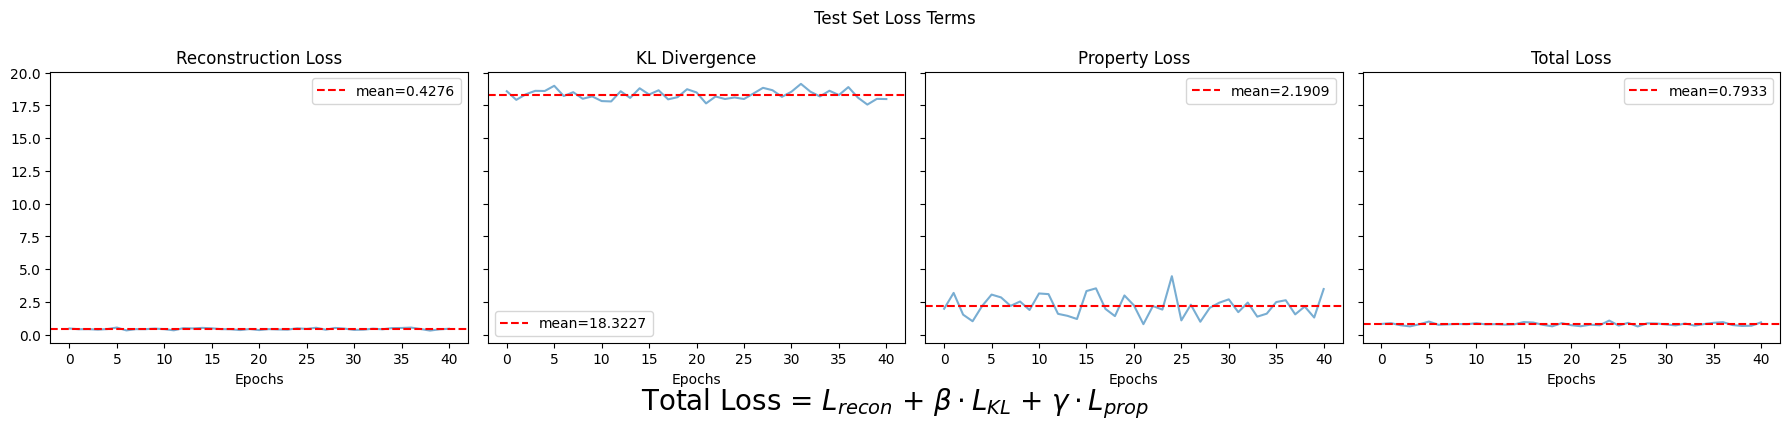

In [44]:
model.eval()
recon_losses, kl_losses, prop_losses, total_losses = [], [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits, mu, log_var, prop_logit = model(x)
        loss, recon, kl, prop = vae_loss(
            logits, x[:, 1:], mu, log_var,
            beta=BETA_MAX,
            prop_logit=prop_logit,
            labels=y.float(),
            gamma=GAMMA,
            kl_free_bits=KL_FREE_BITS
        )
        recon_losses.append(recon.item())
        kl_losses.append(kl.item())
        prop_losses.append(prop.item())
        total_losses.append(loss.item())

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, vals, title in zip(
    axes,
    [recon_losses, kl_losses, prop_losses, total_losses],
    ['Reconstruction Loss', 'KL Divergence', 'Property Loss', 'Total Loss']
):
    ax.plot(vals, alpha=0.6)
    mean = sum(vals) / len(vals)
    ax.axhline(mean, color='red', linestyle='--', label=f'mean={mean:.4f}')
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.legend()

plt.suptitle('Test Set Loss Terms')
plt.tight_layout()
fig.text(
    0.5, -0.02,
    r'Total Loss = $L_{recon}$ + $\beta \cdot L_{KL}$ + $\gamma \cdot L_{prop}$',
    ha='center', fontsize=20
)
plt.show()

## Comparing Before and After Removing SMILES with character length >100

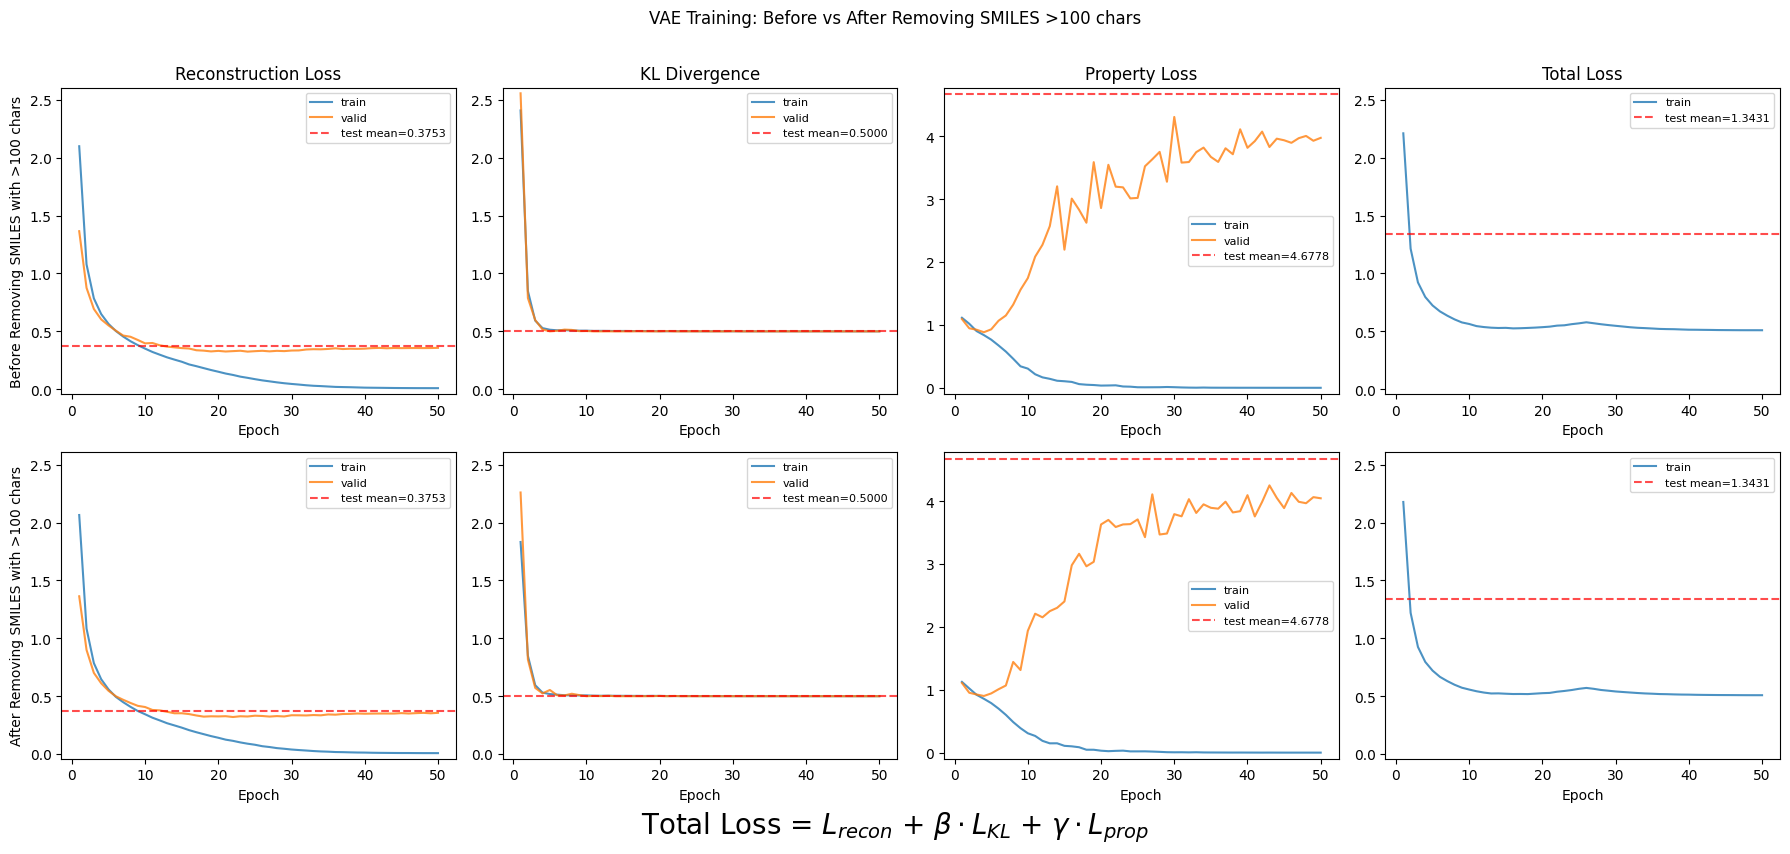

In [42]:
import mlflow
import matplotlib.pyplot as plt

mlflow.set_tracking_uri("file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns")
client = mlflow.tracking.MlflowClient()

def get_metric(run_id, metric_name):
    return [m.value for m in client.get_metric_history(run_id, metric_name)]

run_configs = [
    ("9ccbb8d23c4a468b9a22013501905eeb", "Before Removing SMILES with >100 chars"),
    ("b63cc8d28a9c4f0ea65904f1be08d332", "After Removing SMILES with >100 chars"),
]

test_means = {
    'Reconstruction Loss': 0.3753,
    'KL Divergence':       0.5000,
    'Property Loss':       4.6778,
    'Total Loss':          1.3431,
}

# Fetch all data first
all_data = []
for run_id, title in run_configs:
    data = {
        'train_recon': get_metric(run_id, "recon_loss"),
        'train_kl':    get_metric(run_id, "kl_loss"),
        'train_prop':  get_metric(run_id, "train_prop"),
        'train_total': get_metric(run_id, "train_loss"),
        'valid_recon': get_metric(run_id, "valid_recon"),
        'valid_kl':    get_metric(run_id, "valid_kl"),
        'valid_prop':  get_metric(run_id, "valid_prop"),
    }
    all_data.append((data, title))

# Compute global y-limits across both runs (excluding prop, same as before)
def safe_min(lst): return min(lst) if lst else float('inf')
def safe_max(lst): return max(lst) if lst else float('-inf')

global_min = min(
    safe_min(d['train_recon'] + d['train_kl'] + d['train_total'] + d['valid_recon'] + d['valid_kl'])
    for d, _ in all_data
)
global_max = max(
    safe_max(d['train_recon'] + d['train_kl'] + d['train_total'] + d['valid_recon'] + d['valid_kl'])
    for d, _ in all_data
)

# Also include test_means in the shared y scale so dashed lines are always visible
shared_test_vals = [v for k, v in test_means.items() if k != 'Property Loss']
global_min = min(global_min, min(shared_test_vals))
global_max = max(global_max, max(shared_test_vals))

y_min = global_min - 0.05
y_max = global_max + 0.05

# Prop axis: same logic, global across both runs
global_prop_min = min(
    safe_min(d['train_prop'] + d['valid_prop']) for d, _ in all_data
)
global_prop_max = max(
    safe_max(d['train_prop'] + d['valid_prop']) for d, _ in all_data
)
global_prop_min = min(global_prop_min, test_means['Property Loss'])
global_prop_max = max(global_prop_max, test_means['Property Loss'])
prop_y_min = global_prop_min - 0.1
prop_y_max = global_prop_max + 0.1

# Plot
fig, axes_grid = plt.subplots(2, 4, figsize=(18, 8))

for row, (data, run_title) in enumerate(all_data):
    epochs = range(1, len(data['train_recon']) + 1)
    pairs = [
        (data['train_recon'], data['valid_recon'], 'Reconstruction Loss'),
        (data['train_kl'],    data['valid_kl'],    'KL Divergence'),
        (data['train_prop'],  data['valid_prop'],  'Property Loss'),
        (data['train_total'], None,                'Total Loss'),
    ]
    for col, (train_vals, valid_vals, title) in enumerate(pairs):
        ax = axes_grid[row, col]
        ax.plot(epochs, train_vals, label='train', alpha=0.8)
        if valid_vals is not None:
            ax.plot(epochs, valid_vals, label='valid', alpha=0.8)
        ax.axhline(
            test_means[title], color='red', linestyle='--', alpha=0.7,
            label=f'test mean={test_means[title]:.4f}'
        )
        if row == 0:
            ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(run_title if col == 0 else '')
        ax.legend(fontsize=8)
        if title == 'Property Loss':
            ax.set_ylim(prop_y_min, prop_y_max)
        else:
            ax.set_ylim(y_min, y_max)

plt.suptitle('VAE Training: Before vs After Removing SMILES >100 chars', y=1.01)
plt.tight_layout()
fig.text(
    0.5, -0.02,
    r'Total Loss = $L_{recon}$ + $\beta \cdot L_{KL}$ + $\gamma \cdot L_{prop}$',
    ha='center', fontsize=20
)
plt.show()

# Latent Space Interpolation
To assess whether the latent space is structured, we interpolate between pairs of molecules from the test set. Each molecule is encoded to its mean latent vector mu using the trained encoder. We then compute intermediate vectors along the straight line connecting two latent points:

z_t = (1 - t) * z_A + t * z_B, for t in {0.0, 0.25, 0.5, 0.75, 1.0}

Each z_t is decoded autoregressively (without teacher forcing) to a SMILES string, and RDKit is used to check chemical validity.

In [33]:
def decode_autoregressive(model, z, char2idx, idx2char, max_length, device):
    model.eval()
    sos_token = char2idx['<sos>']
    eos_token = char2idx['<eos>']
    
    input_token = torch.tensor([[sos_token]], device=device)  # (1, 1)
    generated = []
    
    # initialise hidden state from z
    hidden = model.decoder.fc_z(z)
    hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()
    
    with torch.no_grad():
        for _ in range(max_length - 1):
            x_onehot = F.one_hot(input_token, num_classes=model.decoder.vocab_size).float()  # (1, 1, vocab_size)
            z_expanded = z.unsqueeze(1)                                                        # (1, 1, latent_dim)
            gru_input = torch.cat([x_onehot, z_expanded], dim=-1)                             # (1, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logit = model.decoder.fc_out(output)                                               # (1, 1, vocab_size)
            next_token = logit.argmax(dim=-1)                                                  # (1, 1)
            token_id = next_token.item()
            if token_id == eos_token:
                break
            generated.append(token_id)
            input_token = next_token
    
    smiles = ''.join([idx2char[i] for i in generated if idx2char[i] not in ['<sos>', '<pad>', '<eos>']])
    return smiles


# pick two molecules from test set
x_a = test_dataset[0][0].unsqueeze(0).to(device)
x_b = test_dataset[100][0].unsqueeze(0).to(device)

with torch.no_grad():
    z_a, _ = model.encoder(x_a)
    z_b, _ = model.encoder(x_b)

for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    z_t = (1 - t) * z_a + t * z_b
    smiles = decode_autoregressive(model, z_t, char2idx, idx2char, MAX_LENGTH, device)
    mol = Chem.MolFromSmiles(smiles)
    print(f"t={t:.2f}: {smiles} | valid: {mol is not None}")

t=0.00: O=C(c1ccc(F)cc1)OC12CC3CC(CC(C3)C1)C2 | valid: True
t=0.25: O=C(c1ccc(F)cc1)N1CCC2(CCN(Cc3ccccc3)CC2)CC1 | valid: True
t=0.50: COc1ccc(-c2nc3cnc(N4CCOCC4)nc3n(CCC#N)c2=O)cc1 | valid: True
t=0.75: COc1ccc(-n2c(=O)c(CCc3ccccc3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True
t=1.00: COc1ccc(-n2c(=O)c(-c3cccs3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True


In [34]:
pairs = [(0, 100), (5, 200), (10, 300), (50, 400), (15, 250), (80, 350), (20, 450), (3, 180), (60, 120), (90, 500)]
t_values = [0.0, 0.25, 0.5, 0.75, 1.0]

total_intermediate, valid_intermediate = 0, 0

for idx_a, idx_b in pairs:
    x_a = test_dataset[idx_a][0].unsqueeze(0).to(device)
    x_b = test_dataset[idx_b][0].unsqueeze(0).to(device)
    
    with torch.no_grad():
        z_a, _ = model.encoder(x_a)
        z_b, _ = model.encoder(x_b)
    
    print(f"\nPair ({idx_a}, {idx_b})")
    for t in t_values:
        z_t = (1 - t) * z_a + t * z_b
        smiles = decode_autoregressive(model, z_t, char2idx, idx2char, MAX_LENGTH, device)
        mol = Chem.MolFromSmiles(smiles)
        valid = mol is not None
        if t not in [0.0, 1.0]:
            total_intermediate += 1
            valid_intermediate += int(valid)
        print(f"  t={t:.2f}: {smiles} | valid: {valid}")

print(f"\nIntermediate validity (t=0.25, 0.5, 0.75): {valid_intermediate}/{total_intermediate} = {valid_intermediate/total_intermediate:.1%}")


Pair (0, 100)
  t=0.00: O=C(c1ccc(F)cc1)OC12CC3CC(CC(C3)C1)C2 | valid: True
  t=0.25: O=C(c1ccc(F)cc1)N1CCC2(CCN(Cc3ccccc3)CC2)CC1 | valid: True
  t=0.50: COc1ccc(-c2nc3cnc(N4CCOCC4)nc3n(CCC#N)c2=O)cc1 | valid: True
  t=0.75: COc1ccc(-n2c(=O)c(CCc3ccccc3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True
  t=1.00: COc1ccc(-n2c(=O)c(-c3cccs3)nc3cnc(N4CCN(C)CC4)nc32)cc1 | valid: True

Pair (5, 200)
  t=0.00: Cc1cc2ccccc2cc1CN1C(=O)c2cc(-c3ccc(Cl)cc3)ncnc21 | valid: False
  t=0.25: Cc1cc2ccccc2c(C)c1NC(=O)CSc1nc2ccccc2n(C)c1=O | valid: True
  t=0.50: Cc1cc2cc3c(cc2n1)C1CCN(CC(=O)Nc2ccccc2)CC1 | valid: False
  t=0.75: c1ccc2c(c1)N1CCC[C@@]2(CCCN(C)C3)C2)c1 | valid: False
  t=1.00: c1ccc2nc(N3CCC(C(=O)NC4CCCCC4)CC3)ccc2c1 | valid: True

Pair (10, 300)
  t=0.00: Cn1c(=O)c2[nH]c(CCCCc3nc4c([nH]3)c(=O)n(C)c(=O)n4C)nc2n(C)c1=O | valid: True
  t=0.25: Cn1c(=O)c2[nH]c(CCCCc3nc4c(c(=O)n(C)c(=O)n4C)nc32)ccc1=O | valid: False
  t=0.50: Cn1c(=O)c(C(=O)c2ccc(Cl)cc2)nc2cnc(N3CCOCC3)nc21 | valid: True
  t=0.75:

# PCA and UMAP

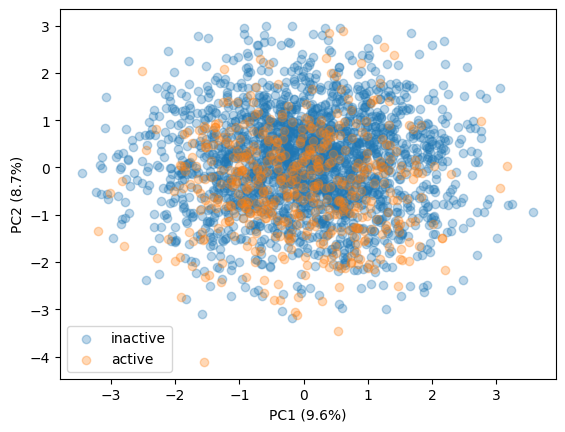

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model.eval()
mus, all_labels = [], []
with torch.no_grad():
    for batch, labels in test_loader:
        batch = batch.to(device)
        mu, _ = model.encoder(batch)
        mus.append(mu.cpu())
        all_labels.append(labels)

mus = torch.cat(mus).numpy()
all_labels = torch.cat(all_labels).numpy()

pca = PCA(n_components=2)
z = pca.fit_transform(mus)

plt.scatter(z[all_labels==0, 0], z[all_labels==0, 1], alpha=0.3, label='inactive')
plt.scatter(z[all_labels==1, 0], z[all_labels==1, 1], alpha=0.3, label='active')
plt.legend()
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.show()

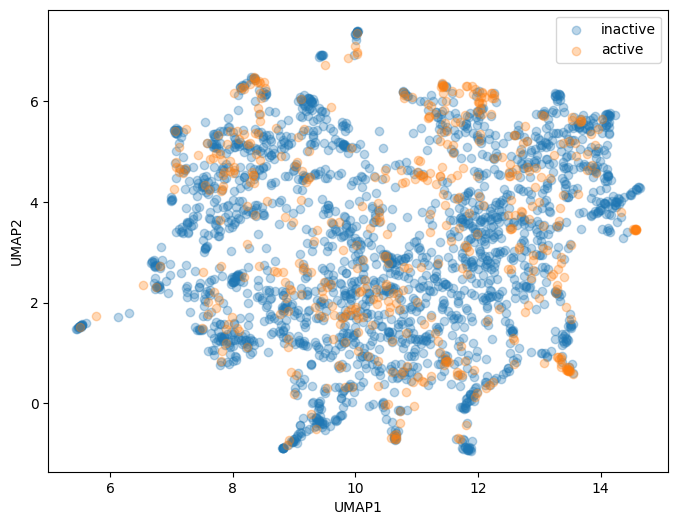

In [39]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
z = reducer.fit_transform(mus)

plt.figure(figsize=(8, 6))
plt.scatter(z[all_labels==0, 0], z[all_labels==0, 1], alpha=0.3, label='inactive')
plt.scatter(z[all_labels==1, 0], z[all_labels==1, 1], alpha=0.3, label='active')
plt.legend()
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()